In [46]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import polars as pl

In [47]:
PASTA_GOLD = Path(
    "../data/gold/anp/precos_mensais_municipio"
)

list(PASTA_GOLD.rglob("*.parquet"))

[PosixPath('../data/gold/anp/precos_mensais_municipio/ano=2023/dados.parquet'),
 PosixPath('../data/gold/anp/precos_mensais_municipio/ano=2025/dados.parquet'),
 PosixPath('../data/gold/anp/precos_mensais_municipio/ano=2024/dados.parquet')]

In [48]:
con = duckdb.connect()

con.execute("""
    CREATE OR REPLACE VIEW precos_mensais AS
    SELECT *
    FROM read_parquet(
        '../data/gold/anp/precos_mensais_municipio/ano=*/dados.parquet'
    )
""")

In [49]:
con.sql("""
    SELECT COUNT(*) AS quantidade_registros
    FROM precos_mensais
""").show()

┌──────────────────────┐
│ quantidade_registros │
│        int64         │
├──────────────────────┤
│                77011 │
└──────────────────────┘



In [50]:
con.sql("""
    SELECT
        MIN(ano_mes) AS primeira_competencia,
        MAX(ano_mes) AS ultima_competencia,
        COUNT(DISTINCT codigo_ibge) AS municipios,
        COUNT(DISTINCT produto) AS produtos
    FROM precos_mensais
""").show()

┌──────────────────────┬────────────────────┬────────────┬──────────┐
│ primeira_competencia │ ultima_competencia │ municipios │ produtos │
│         date         │        date        │   int64    │  int64   │
├──────────────────────┼────────────────────┼────────────┼──────────┤
│ 2023-01-01           │ 2025-12-01         │        462 │        6 │
└──────────────────────┴────────────────────┴────────────┴──────────┘



In [51]:
con.sql("""
    SELECT
        produto,
        COUNT(*) AS registros,
        ROUND(AVG(preco_medio), 2) AS preco_medio
    FROM precos_mensais
    GROUP BY produto
    ORDER BY produto
""").show()

┌────────────────────┬───────────┬─────────────┐
│      produto       │ registros │ preco_medio │
│      varchar       │   int64   │   double    │
├────────────────────┼───────────┼─────────────┤
│ DIESEL             │     13816 │        5.95 │
│ DIESEL S10         │     14618 │        6.04 │
│ ETANOL             │     14477 │        4.27 │
│ GASOLINA           │     14635 │        5.91 │
│ GASOLINA ADITIVADA │     14575 │        6.07 │
│ GNV                │      4890 │        4.86 │
└────────────────────┴───────────┴─────────────┘



## Q1 — Variação regional dos preços

### Visão geral por região e produto

In [52]:
q1_regiao_produto = con.sql("""
    SELECT
        regiao,
        produto,
        ROUND(
            SUM(preco_medio * qtd_coletas) / SUM(qtd_coletas),
            2
        ) AS preco_medio_ponderado,
        SUM(qtd_coletas) AS total_coletas
    FROM precos_mensais
    GROUP BY regiao, produto
    ORDER BY produto, preco_medio_ponderado DESC
""").pl()

q1_regiao_produto

regiao,produto,preco_medio_ponderado,total_coletas
str,str,f64,"decimal[38,0]"
"""Norte""","""DIESEL""",6.4,28209
"""Nordeste""","""DIESEL""",5.95,48186
"""Centro-Oeste""","""DIESEL""",5.93,29185
"""Sul""","""DIESEL""",5.9,61782
"""Sudeste""","""DIESEL""",5.88,127324
…,…,…,…
"""Sul""","""GNV""",5.0,7835
"""Norte""","""GNV""",4.73,235
"""Sudeste""","""GNV""",4.7,35029


In [53]:
q1_regiao_ano = con.sql("""
    SELECT
        YEAR(ano_mes) AS ano,
        regiao,
        produto,
        ROUND(
            SUM(preco_medio * qtd_coletas) / SUM(qtd_coletas),
            2
        ) AS preco_medio_ponderado,
        SUM(qtd_coletas) AS total_coletas
    FROM precos_mensais
    GROUP BY
        YEAR(ano_mes),
        regiao,
        produto
    ORDER BY
        produto,
        ano,
        preco_medio_ponderado DESC
""").pl()

q1_regiao_ano

ano,regiao,produto,preco_medio_ponderado,total_coletas
i64,str,str,f64,"decimal[38,0]"
2023,"""Norte""","""DIESEL""",6.18,10270
2023,"""Nordeste""","""DIESEL""",5.78,17300
2023,"""Centro-Oeste""","""DIESEL""",5.76,10093
2023,"""Sudeste""","""DIESEL""",5.7,46167
2023,"""Sul""","""DIESEL""",5.68,22306
…,…,…,…,…
2025,"""Norte""","""GNV""",5.0,81
2025,"""Sul""","""GNV""",4.94,2495
2025,"""Nordeste""","""GNV""",4.74,3776


In [54]:
q1_gasolina_ano = q1_regiao_ano.filter(
    pl.col("produto") == "GASOLINA"
)

q1_gasolina_ano

ano,regiao,produto,preco_medio_ponderado,total_coletas
i64,str,str,f64,"decimal[38,0]"
2023,"""Norte""","""GASOLINA""",5.92,17171
2023,"""Nordeste""","""GASOLINA""",5.66,45245
2023,"""Sul""","""GASOLINA""",5.56,41192
2023,"""Centro-Oeste""","""GASOLINA""",5.47,17467
2023,"""Sudeste""","""GASOLINA""",5.42,111010
…,…,…,…,…
2025,"""Norte""","""GASOLINA""",6.72,15544
2025,"""Sul""","""GASOLINA""",6.33,37814
2025,"""Nordeste""","""GASOLINA""",6.29,40789


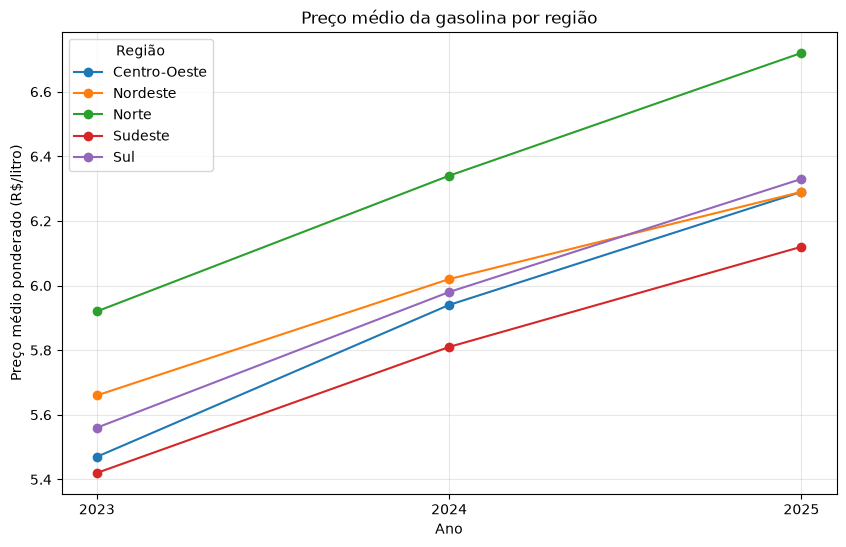

In [55]:
fig, ax = plt.subplots(figsize=(10, 6))

for regiao in q1_gasolina_ano["regiao"].unique().sort():
    dados_regiao = q1_gasolina_ano.filter(
        pl.col("regiao") == regiao
    ).sort("ano")

    ax.plot(
        dados_regiao["ano"],
        dados_regiao["preco_medio_ponderado"],
        marker="o",
        label=regiao,
    )

ax.set_title("Preço médio da gasolina por região")
ax.set_xlabel("Ano")
ax.set_ylabel("Preço médio ponderado (R$/litro)")
ax.set_xticks(q1_gasolina_ano["ano"].unique().sort())
ax.legend(title="Região")
ax.grid(alpha=0.3)

plt.show()

**Interpretação**: Entre 2023 e 2025, observam-se diferenças persistentes no preço médio da gasolina entre as regiões brasileiras. A região Norte apresentou os maiores valores nos três anos analisados, enquanto o Sudeste apresentou os menores. Apesar das diferenças de nível, todas as regiões apresentaram aumento do preço médio ao longo do período.

In [56]:
q1_tabela = (
    q1_regiao_produto
    .pivot(
        index="produto",
        on="regiao",
        values="preco_medio_ponderado",
    )
    .sort("produto")
)

q1_tabela

produto,Norte,Nordeste,Centro-Oeste,Sul,Sudeste
str,f64,f64,f64,f64,f64
"""DIESEL""",6.4,5.95,5.93,5.9,5.88
"""DIESEL S10""",6.4,5.96,6.02,6.0,6.0
"""ETANOL""",4.78,4.57,3.95,4.39,3.95
"""GASOLINA""",6.31,5.98,5.9,5.95,5.77
"""GASOLINA ADITIVADA""",6.5,6.12,6.06,6.09,6.01
"""GNV""",4.73,4.6,4.23,5.0,4.7


**Síntese da Q1**: A análise evidencia diferenças regionais nos preços dos combustíveis entre 2023 e 2025. A região Norte apresentou o maior preço médio ponderado para cinco dos seis produtos analisados: Diesel, Diesel S10, Etanol, Gasolina e Gasolina Aditivada. O GNV apresentou comportamento distinto, com maior preço médio na região Sul. Na análise anual da gasolina, as diferenças regionais também se mostraram persistentes ao longo dos três anos, com o Norte apresentando os maiores valores e o Sudeste os menores. Esses resultados demonstram a existência de padrões regionais, mas não permitem, isoladamente, estabelecer suas causas.

## Q5 — Relação entre Etanol e Gasolina

A relação entre o preço médio do etanol e da gasolina é calculada para o mesmo município e mês. Valores inferiores a 0,70 identificam situações em que o preço do etanol corresponde a menos de 70% do preço da gasolina.

In [57]:
q5_relacao = con.sql("""
    SELECT
        e.ano_mes,
        e.codigo_ibge,
        e.municipio,
        e.uf,
        e.regiao,
        e.preco_medio AS preco_etanol,
        g.preco_medio AS preco_gasolina,
        ROUND(e.preco_medio / g.preco_medio, 3) AS razao_etanol_gasolina
    FROM precos_mensais AS e
    INNER JOIN precos_mensais AS g
        ON e.ano_mes = g.ano_mes
        AND e.codigo_ibge = g.codigo_ibge
    WHERE e.produto = 'ETANOL'
      AND g.produto = 'GASOLINA'
    ORDER BY e.ano_mes, e.codigo_ibge
""").pl()

q5_relacao

ano_mes,codigo_ibge,municipio,uf,regiao,preco_etanol,preco_gasolina,razao_etanol_gasolina
date,str,str,str,str,f64,f64,f64
2023-01-01,"""1100023""","""Ariquemes""","""RO""","""Norte""",4.955714,5.279333,0.939
2023-01-01,"""1100049""","""Cacoal""","""RO""","""Norte""",4.886154,5.4365625,0.899
2023-01-01,"""1100122""","""Ji-Paraná""","""RO""","""Norte""",4.945625,5.251429,0.942
2023-01-01,"""1100205""","""Porto Velho""","""RO""","""Norte""",4.504074,5.026989,0.896
2023-01-01,"""1100304""","""Vilhena""","""RO""","""Norte""",4.614444,5.32,0.867
…,…,…,…,…,…,…,…
2025-12-01,"""5218003""","""Porangatu""","""GO""","""Centro-Oeste""",4.674,6.373077,0.733
2025-12-01,"""5218805""","""Rio Verde""","""GO""","""Centro-Oeste""",4.387571,6.091857,0.72
2025-12-01,"""5221403""","""Trindade""","""GO""","""Centro-Oeste""",4.981765,6.387647,0.78


In [58]:
q5_resumo = con.sql("""
    SELECT
        COUNT(*) AS total,
        COUNT(*) FILTER (
            WHERE razao_etanol_gasolina < 0.70
        ) AS abaixo_070,
        ROUND(
            100.0 * COUNT(*) FILTER (
                WHERE razao_etanol_gasolina < 0.70
            ) / COUNT(*),
            2
        ) AS percentual_abaixo_070
    FROM q5_relacao
""").pl()

q5_resumo

total,abaixo_070,percentual_abaixo_070
i64,i64,f64
14474,5755,39.76


In [59]:
q5_regiao = con.sql("""
    SELECT
        regiao,
        COUNT(*) AS total,
        COUNT(*) FILTER (
            WHERE razao_etanol_gasolina < 0.70
        ) AS abaixo_070,
        ROUND(
            100.0 * COUNT(*) FILTER (
                WHERE razao_etanol_gasolina < 0.70
            ) / COUNT(*),
            2
        ) AS percentual_abaixo_070
    FROM q5_relacao
    GROUP BY regiao
    ORDER BY percentual_abaixo_070 DESC
""").pl()

q5_regiao

regiao,total,abaixo_070,percentual_abaixo_070
str,i64,i64,f64
"""Centro-Oeste""",1031,764,74.1
"""Sudeste""",6638,4096,61.71
"""Sul""",2710,660,24.35
"""Norte""",1005,75,7.46
"""Nordeste""",3090,160,5.18


In [60]:
q5_uf = con.sql("""
    SELECT
        uf,
        regiao,
        COUNT(*) AS total,
        COUNT(*) FILTER (
            WHERE razao_etanol_gasolina < 0.70
        ) AS abaixo_070,
        ROUND(
            100.0 * COUNT(*) FILTER (
                WHERE razao_etanol_gasolina < 0.70
            ) / COUNT(*),
            2
        ) AS percentual_abaixo_070
    FROM q5_relacao
    GROUP BY uf, regiao
    ORDER BY percentual_abaixo_070 DESC
""").pl()

q5_uf

uf,regiao,total,abaixo_070,percentual_abaixo_070
str,str,i64,i64,f64
"""MT""","""Centro-Oeste""",222,212,95.5
"""SP""","""Sudeste""",3540,2923,82.57
"""MS""","""Centro-Oeste""",199,143,71.86
"""GO""","""Centro-Oeste""",574,390,67.94
"""PR""","""Sul""",922,609,66.05
…,…,…,…,…
"""AP""","""Norte""",48,0,0.0
"""MA""","""Nordeste""",377,0,0.0
"""PI""","""Nordeste""",137,0,0.0


**Síntese da Q5**: Entre as 14.474 combinações município-mês com preços disponíveis para etanol e gasolina, 5.755 (39,76%) apresentaram relação Etanol/Gasolina inferior a 0,70. A ocorrência desse indicador apresentou forte concentração regional: Centro-Oeste (74,10%) e Sudeste (61,71%) registraram as maiores proporções, enquanto Norte (7,46%) e Nordeste (5,18%) apresentaram valores consideravelmente menores. No nível estadual, destacaram-se Mato Grosso (95,50%), São Paulo (82,57%), Mato Grosso do Sul (71,86%), Goiás (67,94%) e Paraná (66,05%). Os resultados indicam que a ocorrência da relação inferior a 0,70 possui forte componente geográfico, embora existam diferenças relevantes entre estados de uma mesma região.

## Q4 — Volatilidade dos preços por região e produto

A dispersão dos preços é analisada a partir do desvio-padrão das coletas de preços existente na camada Gold. A métrica representa a variação dos preços observados dentro de cada combinação município-mês-produto.

In [61]:
q4_regiao_produto = con.sql("""
    SELECT
        regiao,
        produto,
        ROUND(AVG(desvio_padrao), 3) AS desvio_padrao_medio,
        COUNT(desvio_padrao) AS total_municipios_mes
    FROM precos_mensais
    WHERE desvio_padrao IS NOT NULL
    GROUP BY regiao, produto
    ORDER BY produto, desvio_padrao_medio DESC
""").pl()

q4_regiao_produto

regiao,produto,desvio_padrao_medio,total_municipios_mes
str,str,f64,i64
"""Sudeste""","""DIESEL""",0.228,6460
"""Norte""","""DIESEL""",0.204,1034
"""Centro-Oeste""","""DIESEL""",0.203,1026
"""Sul""","""DIESEL""",0.19,2681
"""Nordeste""","""DIESEL""",0.182,2378
…,…,…,…
"""Sul""","""GNV""",0.08,939
"""Sudeste""","""GNV""",0.077,2455
"""Norte""","""GNV""",0.054,36


In [62]:
q4_tabela = (
    q4_regiao_produto
    .select([
        "produto",
        "regiao",
        "desvio_padrao_medio",
    ])
    .pivot(
        index="produto",
        on="regiao",
        values="desvio_padrao_medio",
    )
    .sort("produto")
)

q4_tabela

produto,Sudeste,Norte,Centro-Oeste,Sul,Nordeste
str,f64,f64,f64,f64,f64
"""DIESEL""",0.228,0.204,0.203,0.19,0.182
"""DIESEL S10""",0.254,0.225,0.208,0.205,0.196
"""ETANOL""",0.183,0.155,0.141,0.187,0.153
"""GASOLINA""",0.204,0.119,0.144,0.126,0.121
"""GASOLINA ADITIVADA""",0.237,0.145,0.173,0.174,0.15
"""GNV""",0.077,0.054,0.043,0.08,0.03


**Síntese da Q4**: A dispersão dos preços apresenta diferenças entre regiões e produtos. Considerando a média dos desvios-padrão observados em cada município-mês, o Sudeste apresentou os maiores valores para Diesel, Diesel S10, Gasolina e Gasolina Aditivada. Para Etanol e GNV, os maiores valores foram observados na região Sul. A análise representa a dispersão dos preços entre as coletas realizadas dentro de cada município-mês, não a volatilidade temporal dos preços. A dimensão relacionada ao tamanho dos municípios não foi avaliada nesta implementação, pois depende da integração dos dados populacionais do IBGE prevista na arquitetura.